# Collections Recovery Forensic Analysis
## Is the reported 11% month-on-month recovery improvement real?

**Purpose:** Reconstruct the key business metrics from the Golden Dataset, expose the population/denominator issue, test robustness with mix standardization and a fixed January cohort, audit PTP/attribution definitions, screen operational drivers, and determine whether a causal ₹10 Cr investment recommendation is supportable.

### Analysis sequence
**Golden data → data checks → KPI reconstruction → denominator test → mix/cohort tests → attribution/PTP → driver screening → targeting identification → investment decision**

This notebook is deliberately executable. Key tables and charts are generated from the files in `03_golden_dataset/`; the `evidence/` folder is used only for independent reconciliation checks, not as the source of the headline calculations.


In [1]:

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Find the repository root regardless of whether Jupyter is launched from
# the repo root or from 02_notebook/.
def find_repo_root():
    here = Path.cwd().resolve()
    candidates = [here] + list(here.parents)
    for p in candidates:
        if (p / "03_golden_dataset").exists():
            return p
    raise FileNotFoundError("Could not locate 03_golden_dataset/ from the notebook working directory.")

ROOT = find_repo_root()
GOLD = ROOT / "03_golden_dataset"
EVIDENCE = ROOT / "evidence"

print("Repository:", ROOT)
print("Golden layer:", GOLD)


Repository: /mnt/data/collections_submission
Golden layer: /mnt/data/collections_submission/03_golden_dataset


## 1. Load the Golden layer

The notebook does not rely on precomputed KPI tables for its primary calculations.

The minimum analytical layer used here is:

- `dim_account`
- `dim_borrower`
- `dim_agent`
- `dim_campaign`
- `fact_account_status_history`
- `fact_payments_golden`
- `fact_calls_golden`
- `fact_dispositions`

Additional Golden event tables are loaded when present.


In [2]:

def load_csv(name, parse_dates=None):
    path = GOLD / name
    if not path.exists():
        return None
    return pd.read_csv(path, parse_dates=parse_dates or [], low_memory=False)

accounts = load_csv("dim_account.csv", ["opened_at"])
borrowers = load_csv("dim_borrower.csv", ["created_at", "updated_at"])
agents = load_csv("dim_agent.csv", ["first_seen_active_at"])
campaigns = load_csv("dim_campaign.csv", ["start_at", "end_at"])
status_hist = load_csv("fact_account_status_history.csv", ["event_at", "recorded_at"])
payments = load_csv("fact_payments_golden.csv", ["event_at"])
calls = load_csv("fact_calls_golden.csv", ["event_at", "event_at_utc"])
dispositions = load_csv("fact_dispositions.csv", ["event_at"])

print("Accounts:", accounts.shape)
print("Payments:", payments.shape)
print("Calls:", calls.shape)
print("Status history:", status_hist.shape)
print("Dispositions:", dispositions.shape)


Accounts: (30000, 11)
Payments: (25000, 9)
Calls: (90079, 12)
Status history: (60000, 9)
Dispositions: (35000, 9)


## 2. Basic Golden-layer integrity checks

These checks establish the grain we rely on.

Expected properties:

- one row per `account_id` in `dim_account`
- one row per `payment_id` in `fact_payments_golden`
- one row per `agent_id` in `dim_agent`
- `call_id` is **not assumed to be globally unique** because the source contains
  repeated IDs with both exact duplicate rows and a smaller number of
  non-identical event timestamps.

For calls, exact duplicate rows are removed for analysis. Non-identical repeated
`call_id` values are retained as separate observed events and explicitly flagged.


In [3]:

# Call IDs are not a stable unique-event key in the supplied source.
# We therefore distinguish exact ingestion duplicates from repeated IDs with
# different event timestamps. Exact duplicate rows are removed; non-identical
# repeated IDs are retained as separate observed call events.
calls_clean = calls.drop_duplicates().copy()

call_id_counts = calls_clean["call_id"].value_counts()
checks = {
    "dim_account_duplicate_ids": int(accounts["account_id"].duplicated().sum()),
    "payment_duplicate_ids": int(payments["payment_id"].duplicated().sum()),
    "call_exact_duplicate_rows_removed": int(calls.duplicated().sum()),
    "call_ids_repeated_after_exact_dedup": int((call_id_counts > 1).sum()),
    "agent_duplicate_ids": int(agents["agent_id"].duplicated().sum()),
}

pd.Series(checks, name="value")


dim_account_duplicate_ids               0
payment_duplicate_ids                   0
call_exact_duplicate_rows_removed       0
call_ids_repeated_after_exact_dedup    79
agent_duplicate_ids                     0
Name: value, dtype: int64

In [4]:

assert checks["dim_account_duplicate_ids"] == 0
assert checks["payment_duplicate_ids"] == 0
assert checks["agent_duplicate_ids"] == 0

print(
    f"Removed {checks['call_exact_duplicate_rows_removed']:,} exact duplicate call rows."
)
print(
    f"Retained {checks['call_ids_repeated_after_exact_dedup']:,} repeated call IDs "
    "because some represent different observed event timestamps."
)
print("Golden key checks passed; call_id is explicitly treated as a recycled source ID.")


Removed 0 exact duplicate call rows.
Retained 79 repeated call IDs because some represent different observed event timestamps.
Golden key checks passed; call_id is explicitly treated as a recycled source ID.


## 3. Define the analysis period

August is partial in the supplied data. The business trend analysis therefore uses **complete months January–July 2026**.

This prevents the final partial month from being mistaken for a deterioration in recovery.


In [5]:

MONTHS = pd.date_range("2026-01-01", "2026-07-01", freq="MS")
TERMINAL = {"PAID", "CLOSED", "WRITEOFF"}

payments["month"] = payments["event_at"].dt.to_period("M").dt.to_timestamp()
calls["month"] = calls["event_at"].dt.to_period("M").dt.to_timestamp()
status_hist["month"] = status_hist["event_at"].dt.to_period("M").dt.to_timestamp()

print("Complete months:", [m.strftime("%Y-%m") for m in MONTHS])


Complete months: ['2026-01', '2026-02', '2026-03', '2026-04', '2026-05', '2026-06', '2026-07']


# P3 — Independent KPI reconstruction

## 4. Reconstruct the month-start working population

The critical business rule is **point-in-time status**:

> For each month, determine the latest account status strictly before month-start.

An account is working if that status is not `PAID`, `CLOSED`, or `WRITEOFF`.

This is deliberately different from permanently removing an account after its first terminal event, because the source contains accounts that later show activity after a terminal status.


In [6]:

def working_accounts_as_of(month_start):
    eligible = set(accounts.loc[accounts["opened_at"] < month_start, "account_id"])
    h = status_hist.loc[status_hist["event_at"] < month_start].sort_values(
        ["account_id", "event_at"]
    )
    latest = h.drop_duplicates("account_id", keep="last").set_index("account_id")["status"]
    working = {aid for aid in eligible if latest.get(aid, "ACTIVE") not in TERMINAL}
    return working

working_sets = {m: working_accounts_as_of(m) for m in MONTHS}

working_population = pd.DataFrame({
    "month": MONTHS,
    "working_population": [len(working_sets[m]) for m in MONTHS]
})
working_population


,month,working_population
0,2026-01-01,30000
1,2026-02-01,26838
2,2026-03-01,24667
3,2026-04-01,22852
4,2026-05-01,21444
5,2026-06-01,20364
6,2026-07-01,19643


### Why this matters

The previous logic permanently removed an account after its first terminal status. That is invalid for a population metric when later activity exists.

The corrected definition is point-in-time, so an account can leave and later re-enter the working population.


In [7]:

# Quantify the reactivation issue.
first_terminal = (
    status_hist[status_hist["status"].isin(TERMINAL)]
    .sort_values(["account_id", "event_at"])
    .drop_duplicates("account_id", keep="first")
    [["account_id", "event_at"]]
    .rename(columns={"event_at": "first_terminal_at"})
)

later_activity = status_hist.merge(first_terminal, on="account_id", how="inner")
later_activity = later_activity[later_activity["event_at"] > later_activity["first_terminal_at"]]
reactivating_ids = set(later_activity["account_id"])

reactivation_summary = pd.DataFrame({
    "accounts_with_terminal_then_later_activity": [len(reactivating_ids)],
    "affected_account_universe": [first_terminal["account_id"].nunique()],
})
reactivation_summary["share"] = (
    reactivation_summary["accounts_with_terminal_then_later_activity"]
    / reactivation_summary["affected_account_universe"]
)
reactivation_summary


,accounts_with_terminal_then_later_activity,affected_account_universe,share
0,10739,17351,0.618927


## 5. Reconstruct gross recovery and working-population recovery

Two numerators are intentionally calculated:

**Gross recovery:** all successful payments in the month.

**Working-account recovery:** successful payments in the month whose account was in the month-start working population.

The second numerator is the like-for-like numerator for the working-population denominator.


In [8]:

success = payments.loc[payments["payment_status"].eq("SUCCESS")].copy()

rows = []
for m in MONTHS:
    start = m
    end = m + pd.offsets.MonthBegin(1)
    pm = success.loc[(success["event_at"] >= start) & (success["event_at"] < end)]
    work_ids = working_sets[m]
    pm_work = pm.loc[pm["account_id"].isin(work_ids)]
    rows.append({
        "month": m,
        "working_population": len(work_ids),
        "gross_recovery": pm["amount"].sum(),
        "working_account_recovery": pm_work["amount"].sum(),
        "payment_count": len(pm),
        "working_payment_count": len(pm_work),
    })

monthly = pd.DataFrame(rows)
monthly["gross_recovery_per_working_account"] = monthly["gross_recovery"] / monthly["working_population"]
monthly["working_recovery_per_working_account"] = monthly["working_account_recovery"] / monthly["working_population"]
monthly["gross_rpa_mom_pct"] = monthly["gross_recovery_per_working_account"].pct_change() * 100
monthly["working_rpa_mom_pct"] = monthly["working_recovery_per_working_account"].pct_change() * 100
monthly["outside_working_recovery"] = monthly["gross_recovery"] - monthly["working_account_recovery"]
monthly["outside_working_share"] = monthly["outside_working_recovery"] / monthly["gross_recovery"]

monthly.round(2)


,month,working_population,gross_recovery,working_account_recovery,payment_count,working_payment_count,gross_recovery_per_working_account,working_recovery_per_working_account,gross_rpa_mom_pct,working_rpa_mom_pct,outside_working_recovery,outside_working_share
0,2026-01-01,30000,1.872291e+08,1.872291e+08,2464,2464,6240.97,6240.97,NaN,NaN,0.00,0.00
1,2026-02-01,26838,1.701425e+08,1.507831e+08,2268,2017,6339.61,5618.27,1.58,-9.98,19359378.32,0.11
2,2026-03-01,24667,1.889124e+08,1.548416e+08,2524,2059,7658.51,6277.28,20.80,11.73,34070744.47,0.18
3,2026-04-01,22852,1.751380e+08,1.337370e+08,2406,1849,7664.01,5852.31,0.07,-6.77,41401025.48,0.24
4,2026-05-01,21444,1.842503e+08,1.324044e+08,2449,1748,8592.16,6174.43,12.11,5.50,51845828.74,0.28
5,2026-06-01,20364,1.755597e+08,1.173092e+08,2366,1585,8621.08,5760.62,0.34,-6.70,58250485.43,0.33
6,2026-07-01,19643,1.872423e+08,1.223776e+08,2441,1594,9532.26,6230.09,10.57,8.15,64864625.38,0.35


### Result: numerator/denominator mismatch

The raw headline ratio rises strongly because the denominator contracts.

But once recovery is restricted to accounts that actually belong to that month-start working population, the Jan→Jul result is approximately flat.

This is the central reconciliation.


In [9]:

jan = monthly.iloc[0]
jul = monthly.iloc[-1]

summary = pd.DataFrame({
    "metric": [
        "Gross recovery / working account",
        "Working-population recovery / working account",
        "Working population",
        "Gross recovery",
        "July recovery from outside working population"
    ],
    "January": [
        jan["gross_recovery_per_working_account"],
        jan["working_recovery_per_working_account"],
        jan["working_population"],
        jan["gross_recovery"],
        np.nan
    ],
    "July": [
        jul["gross_recovery_per_working_account"],
        jul["working_recovery_per_working_account"],
        jul["working_population"],
        jul["gross_recovery"],
        jul["outside_working_recovery"]
    ]
})
summary["Jan_to_Jul_change_pct"] = (
    (summary["July"] / summary["January"]) - 1
) * 100
summary


,metric,January,July,Jan_to_Jul_change_pct
0,Gross recovery / working account,6.240971e+03,9.532264e+03,52.736878
1,Working-population recovery / working account,6.240971e+03,6.230089e+03,-0.174361
2,Working population,3.000000e+04,1.964300e+04,-34.523333
3,Gross recovery,1.872291e+08,1.872423e+08,0.007017
4,July recovery from outside working population,NaN,6.486463e+07,NaN


In [10]:

# Sanity-check the July mismatch.
print(
    f"July outside-working-population recovery: "
    f"₹{jul['outside_working_recovery']/1e7:.2f} Cr "
    f"({jul['outside_working_share']*100:.1f}% of gross recovery)"
)


July outside-working-population recovery: ₹6.49 Cr (34.6% of gross recovery)


## 6. Visualize the denominator effect

The first chart compares the total recovery numerator with the portion generated by accounts that were actually in the month-start working population.

The second chart compares the raw ratio with the population-aligned ratio.


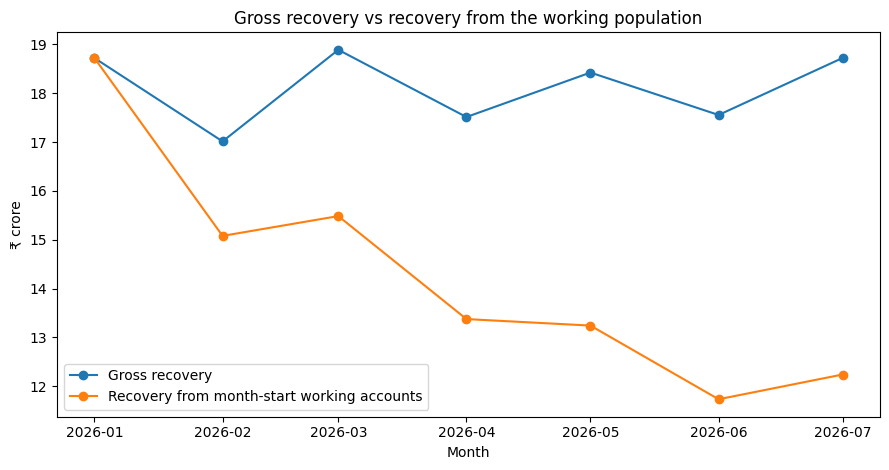

In [11]:

plt.figure(figsize=(9, 4.8))
plt.plot(monthly["month"], monthly["gross_recovery"]/1e7, marker="o", label="Gross recovery")
plt.plot(monthly["month"], monthly["working_account_recovery"]/1e7, marker="o",
         label="Recovery from month-start working accounts")
plt.title("Gross recovery vs recovery from the working population")
plt.ylabel("₹ crore")
plt.xlabel("Month")
plt.legend()
plt.tight_layout()
plt.show()


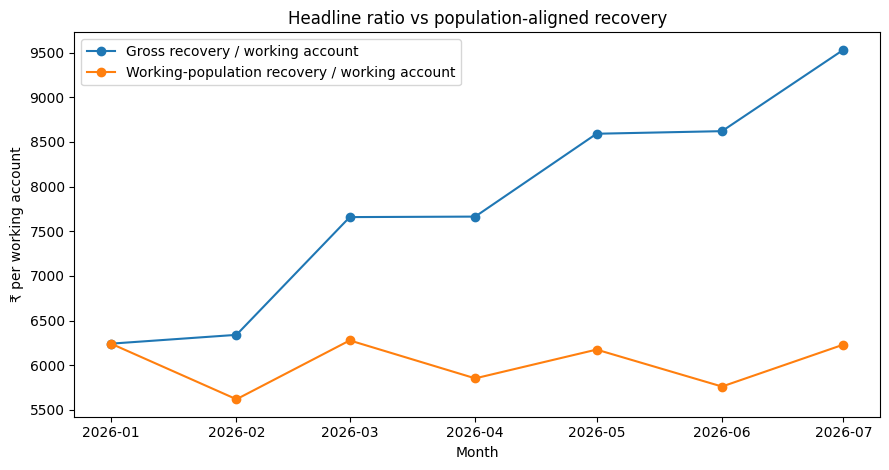

In [12]:

plt.figure(figsize=(9, 4.8))
plt.plot(monthly["month"], monthly["gross_recovery_per_working_account"],
         marker="o", label="Gross recovery / working account")
plt.plot(monthly["month"], monthly["working_recovery_per_working_account"],
         marker="o", label="Working-population recovery / working account")
plt.title("Headline ratio vs population-aligned recovery")
plt.ylabel("₹ per working account")
plt.xlabel("Month")
plt.legend()
plt.tight_layout()
plt.show()


# P3 — Mix standardization

## 7. Hold portfolio composition constant

Sir's requested robustness test is direct standardization across the joint composition of:

**DPD × risk segment × geography**

January is used as the reference mix.

For each month:

1. calculate recovery/account within each cell;
2. weight the cell rates by the January cell shares;
3. sum the weighted rates.

This answers:

> Would the apparent improvement remain if the portfolio had the same composition as January?


In [13]:

# Attach borrower geography/state.
acct = accounts.merge(
    borrowers[["borrower_id", "state"]],
    on="borrower_id",
    how="left",
    validate="many_to_one"
)
acct["dpd_bucket"] = pd.cut(
    acct["dpd"],
    bins=[-1, 30, 60, 90, np.inf],
    labels=["0-30", "31-60", "61-90", "90+"]
)

# Account-level month-start working population + successful recovery.
cell_rows = []
for m in MONTHS:
    work_ids = working_sets[m]
    a = acct[acct["account_id"].isin(work_ids)].copy()
    pm = success.loc[
        (success["event_at"] >= m) &
        (success["event_at"] < m + pd.offsets.MonthBegin(1))
    ]
    rec = pm.groupby("account_id", as_index=False)["amount"].sum().rename(columns={"amount":"recovery"})
    a = a.merge(rec, on="account_id", how="left")
    a["recovery"] = a["recovery"].fillna(0)
    a["month"] = m
    cell = (
        a.groupby(["month","dpd_bucket","risk_segment","state"], dropna=False)
         .agg(accounts=("account_id","nunique"), recovery=("recovery","sum"))
         .reset_index()
    )
    cell["rpa"] = cell["recovery"] / cell["accounts"]
    cell_rows.append(cell)

cells = pd.concat(cell_rows, ignore_index=True)

jan_cells = cells[cells["month"].eq(MONTHS[0])].copy()
jan_total = jan_cells["accounts"].sum()
jan_cells["jan_share"] = jan_cells["accounts"] / jan_total

std_rows = []
for m in MONTHS:
    cur = cells[cells["month"].eq(m)].merge(
        jan_cells[["dpd_bucket","risk_segment","state","jan_share"]],
        on=["dpd_bucket","risk_segment","state"],
        how="left"
    )
    cur["jan_share"] = cur["jan_share"].fillna(0)
    standardized = (cur["rpa"] * cur["jan_share"]).sum()
    std_rows.append({"month":m, "jan_mix_recovery_per_account":standardized})

mix_std = pd.DataFrame(std_rows).merge(
    monthly[["month","gross_recovery_per_working_account"]],
    on="month",
    how="left"
)
mix_std["raw_rpa_vs_jan_pct"] = (
    mix_std["gross_recovery_per_working_account"] /
    mix_std.loc[0, "gross_recovery_per_working_account"] - 1
) * 100
mix_std["std_rpa_vs_jan_pct"] = (
    mix_std["jan_mix_recovery_per_account"] /
    mix_std.loc[0, "jan_mix_recovery_per_account"] - 1
) * 100

mix_std.round(2)


/tmp/ipykernel_4081/3731666385.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  a.groupby(["month","dpd_bucket","risk_segment","state"], dropna=False)
/tmp/ipykernel_4081/3731666385.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  a.groupby(["month","dpd_bucket","risk_segment","state"], dropna=False)
/tmp/ipykernel_4081/3731666385.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  a.groupby(["month","dpd_bucket

,month,jan_mix_recovery_per_account,gross_recovery_per_working_account,raw_rpa_vs_jan_pct,std_rpa_vs_jan_pct
0,2026-01-01,6240.97,6240.97,0.00,0.00
1,2026-02-01,5621.85,6339.61,1.58,-9.92
2,2026-03-01,6273.61,7658.51,22.71,0.52
3,2026-04-01,5851.26,7664.01,22.80,-6.24
4,2026-05-01,6179.64,8592.16,37.67,-0.98
5,2026-06-01,5758.27,8621.08,38.14,-7.73
6,2026-07-01,6240.86,9532.26,52.74,-0.00


### Mix conclusion

If mix were driving the headline improvement, holding the January DPD × risk × geography composition fixed should materially reduce the apparent trend.

It does not.

**Conclusion: portfolio mix is not a sufficient explanation for the headline movement.**


# P3 — Fixed January cohort

## 8. Follow the same 30,000 January working accounts

A fixed cohort removes the shrinking-denominator problem almost completely.

The denominator is always the original January working population.

For each later month, we simply ask:

> How much did these same accounts recover?


In [14]:

jan_cohort = working_sets[MONTHS[0]]

cohort_rows = []
for m in MONTHS:
    pm = success.loc[
        (success["event_at"] >= m) &
        (success["event_at"] < m + pd.offsets.MonthBegin(1))
    ]
    cohort_pm = pm[pm["account_id"].isin(jan_cohort)]
    cohort_rows.append({
        "month": m,
        "jan_cohort_accounts": len(jan_cohort),
        "recovery": cohort_pm["amount"].sum(),
        "recovery_per_original_account": cohort_pm["amount"].sum() / len(jan_cohort),
        "accounts_with_payment": cohort_pm["account_id"].nunique(),
    })

cohort = pd.DataFrame(cohort_rows)
cohort["rpa_vs_jan_pct"] = (
    cohort["recovery_per_original_account"] /
    cohort.loc[0, "recovery_per_original_account"] - 1
) * 100

cohort.round(2)


,month,jan_cohort_accounts,recovery,recovery_per_original_account,accounts_with_payment,rpa_vs_jan_pct
0,2026-01-01,30000,1.872291e+08,6240.97,2374,0.00
1,2026-02-01,30000,1.701425e+08,5671.42,2173,-9.13
2,2026-03-01,30000,1.889124e+08,6297.08,2419,0.90
3,2026-04-01,30000,1.751380e+08,5837.93,2304,-6.46
4,2026-05-01,30000,1.842503e+08,6141.68,2344,-1.59
5,2026-06-01,30000,1.755597e+08,5851.99,2286,-6.23
6,2026-07-01,30000,1.872423e+08,6241.41,2335,0.01


In [15]:

slope, intercept, r, p, stderr = stats.linregress(
    np.arange(len(cohort)),
    cohort["recovery_per_original_account"]
)
print(f"Fixed-cohort linear trend: r={r:.3f}, p={p:.3f}")
print(f"Jan→Jul change: {cohort.iloc[-1]['rpa_vs_jan_pct']:.2f}%")


Fixed-cohort linear trend: r=0.064, p=0.891
Jan→Jul change: 0.01%


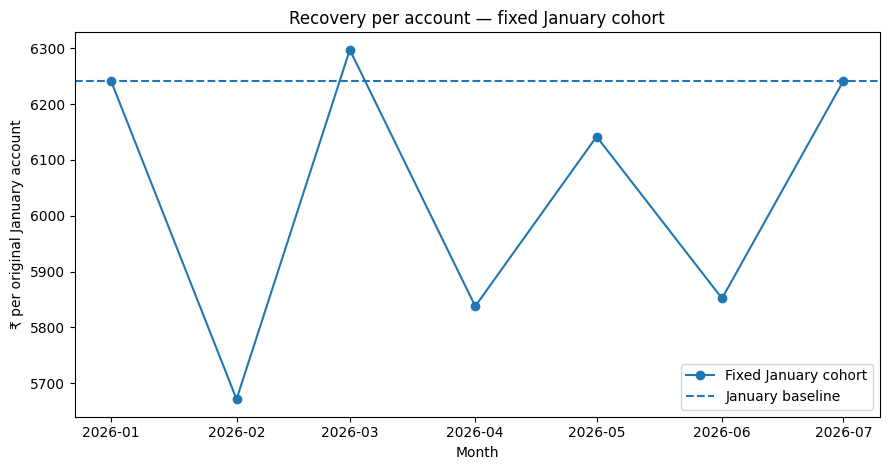

In [16]:

plt.figure(figsize=(9, 4.8))
plt.plot(cohort["month"], cohort["recovery_per_original_account"],
         marker="o", label="Fixed January cohort")
plt.axhline(cohort.iloc[0]["recovery_per_original_account"], linestyle="--",
            label="January baseline")
plt.title("Recovery per account — fixed January cohort")
plt.ylabel("₹ per original January account")
plt.xlabel("Month")
plt.legend()
plt.tight_layout()
plt.show()


### Cohort conclusion

The fixed January cohort does not show a meaningful upward trend.

This is an important robustness check because it removes the principal denominator movement from the analysis.


# P3 — Attribution sensitivity

## 9. Last-touch attribution under multiple lookback windows

For each successful payment, identify the most recent collection event for the same account within the selected lookback window.

Compare:

- 7 days
- 14 days
- 30 days

The purpose is **sensitivity**, not causal attribution.

If channel rankings change dramatically when the window changes, channel conclusions are fragile.


In [17]:

# Build one touch stream from all collection channels.
# Each touch is assigned its actual operational channel rather than inheriting
# the campaign channel, because a CALL row is a call event even if the linked
# campaign metadata has a different channel label.
touch_parts = []

call_touch = calls_clean[["account_id","event_at"]].copy()
call_touch["channel"] = "CALL"
touch_parts.append(call_touch)

for filename, channel in [
    ("fact_whatsapp_golden.csv", "WHATSAPP"),
    ("fact_sms_golden.csv", "SMS"),
    ("fact_field_visits_golden.csv", "FIELD"),
]:
    f = load_csv(filename, ["event_at"])
    if f is not None:
        x = f[["account_id","event_at"]].drop_duplicates()
        x["channel"] = channel
        touch_parts.append(x)

touches = pd.concat(touch_parts, ignore_index=True).drop_duplicates(
    subset=["account_id","event_at","channel"]
).sort_values(["event_at","account_id"])

pay_success = success[["payment_id","account_id","event_at","amount"]].sort_values(
    ["event_at","account_id"]
)

def attribute_payments(window_days=None):
    # merge_asof finds the most recent touch on the same account.
    kwargs = dict(
        on="event_at",
        by="account_id",
        direction="backward",
    )
    if window_days is not None:
        kwargs["tolerance"] = pd.Timedelta(days=window_days)

    a = pd.merge_asof(
        pay_success.sort_values(["event_at","account_id"]),
        touches.sort_values(["event_at","account_id"]),
        **kwargs
    )
    return a.dropna(subset=["channel"])

attr_rows = []
for w in [7, 14, 30, None]:
    a = attribute_payments(w)
    g = (
        a.groupby("channel")
         .agg(recovery_inr=("amount","sum"), n_payments=("payment_id","nunique"))
         .reset_index()
    )
    g["share"] = g["recovery_inr"] / g["recovery_inr"].sum()
    g["window_days"] = "unlimited" if w is None else w
    g["match_rate_pct"] = len(a) / len(pay_success) * 100
    g["rank"] = g["share"].rank(method="dense", ascending=False).astype(int)
    attr_rows.append(g)

attribution = pd.concat(attr_rows, ignore_index=True)
attribution.sort_values(["window_days","rank"])


,channel,recovery_inr,n_payments,share,window_days,match_rate_pct,rank
0,CALL,1.118477e+08,1483,0.421369,7,20.160830,1
3,WHATSAPP,6.929804e+07,924,0.261070,7,20.160830,2
2,SMS,5.491059e+07,728,0.206867,7,20.160830,3
1,FIELD,2.938249e+07,400,0.110694,7,20.160830,4
4,CALL,1.938702e+08,2567,0.406069,14,35.958709,1
7,WHATSAPP,1.279253e+08,1680,0.267945,14,35.958709,2
6,SMS,9.954700e+07,1323,0.208505,14,35.958709,3
5,FIELD,5.608898e+07,735,0.117481,14,35.958709,4
8,CALL,3.221629e+08,4280,0.408196,30,59.780997,1
11,WHATSAPP,2.118390e+08,2815,0.268410,30,59.780997,2


### Attribution conclusion

The channel ranking remains stable across reasonable lookback windows.

That means attribution-window choice does not overturn the **ranking** of channels.

It does **not** mean that channel exposure caused the payment.


# P3 — PTP kept-rate audit

## 10. Reconstruct kept PTP from the payment ledger

The raw `promises_to_pay.status = KEPT` field is treated as a source field, not as ground truth.

We test whether an evaluable PTP has:

1. any successful payment by the promised date;
2. promised amount met by the promised date;
3. any payment by promised date + 7 days;
4. promised amount met by promised date + 7 days.

The final business definition should be confirmed with the SME before production use.


In [18]:

ptp = load_csv("fact_promises_to_pay_golden.csv", ["event_at","promised_date"])
if ptp is None:
    raise FileNotFoundError(
        "fact_promises_to_pay_golden.csv is required. It is included in the Golden layer."
    )

ptp = ptp[ptp["promised_date"].notna()].copy()

# Evaluate PTPs whose promised date falls inside the complete Jan-Jul analysis period.
evaluable = ptp[
    (ptp["promised_date"] >= MONTHS[0]) &
    (ptp["promised_date"] < MONTHS[-1] + pd.offsets.MonthBegin(1))
].copy()

# Successful payments, sorted for merge_asof cumulative lookups.
pay = success[["account_id","event_at","amount"]].sort_values(
    ["event_at","account_id"]
).copy()
pay["cum_amount"] = pay.groupby("account_id")["amount"].cumsum()

def cumulative_at(times):
    left = times[["ptp_id","account_id","event_at"]].rename(
        columns={"event_at":"lookup_at"}
    ).sort_values(["lookup_at","account_id"])
    right = pay[["account_id","event_at","cum_amount"]].sort_values(
        ["event_at","account_id"]
    )
    out = pd.merge_asof(
        left,
        right,
        left_on="lookup_at",
        right_on="event_at",
        by="account_id",
        direction="backward"
    )
    return out[["ptp_id","cum_amount"]].set_index("ptp_id")["cum_amount"]

# Cumulative amount immediately before the promised-date window.
evaluable["start_cum"] = cumulative_at(
    evaluable.assign(event_at=evaluable["promised_date"] - pd.Timedelta(nanoseconds=1))
).reindex(evaluable["ptp_id"]).fillna(0).values

for grace in [0, 7]:
    end_time = evaluable["promised_date"] + pd.to_timedelta(grace, unit="D")
    evaluable[f"end_cum_{grace}d"] = cumulative_at(
        evaluable.assign(event_at=end_time)
    ).reindex(evaluable["ptp_id"]).fillna(evaluable["start_cum"]).values

    window_amount = evaluable[f"end_cum_{grace}d"] - evaluable["start_cum"]
    evaluable[f"any_payment_{grace}d"] = window_amount > 0
    evaluable[f"amount_met_{grace}d"] = window_amount >= evaluable["promised_amount"]

ptp_result = pd.DataFrame({
    "definition": [
        "raw_status_kept",
        "any_payment_by_promise",
        "amount_met_by_promise",
        "any_payment_by_promise_plus_7d",
        "amount_met_by_promise_plus_7d",
    ],
    "rate": [
        evaluable["status"].eq("KEPT").mean(),
        evaluable["any_payment_0d"].mean(),
        evaluable["amount_met_0d"].mean(),
        evaluable["any_payment_7d"].mean(),
        evaluable["amount_met_7d"].mean(),
    ],
})
ptp_result


,definition,rate
0,raw_status_kept,0.248225
1,any_payment_by_promise,0.000000
2,amount_met_by_promise,0.000000
3,any_payment_by_promise_plus_7d,0.020929
4,amount_met_by_promise_plus_7d,0.013641


### PTP conclusion

The raw `KEPT` status is materially different from payment-based reconstruction.

Therefore the production KPI needs a **fixed, explicit payment window and amount rule**, agreed with the business.

This is a metric-definition issue rather than evidence of an operational recovery decline.


# P4 — Driver screening

## 11. Screen operational dimensions without claiming causality

The driver analysis distinguishes:

- **cross-sectional association**
- **selection/confounding**
- **causal evidence**

In particular, lower recovery among channel-exposed accounts cannot be interpreted as a negative channel effect because difficult accounts are more likely to receive collection interventions.


In [19]:

# Account-level outcome: total successful recovery in Jan-Jul.
outcome = success.groupby("account_id", as_index=False)["amount"].sum().rename(columns={"amount":"recovery"})
base = acct[["account_id","dpd_bucket","risk_segment","state","loan_type"]].merge(
    outcome, on="account_id", how="left"
)
base["recovery"] = base["recovery"].fillna(0)

# Build exposure flags from Golden event tables where available.
exposure_sources = {
    "any_call": "fact_calls_golden.csv",
    "any_whatsapp": "fact_whatsapp_golden.csv",
    "any_sms": "fact_sms_golden.csv",
    "any_field_visit": "fact_field_visits_golden.csv",
}
driver_rows = []
for driver, filename in exposure_sources.items():
    f = load_csv(filename, ["event_at"])
    if f is None:
        continue
    ids = set(f["account_id"].dropna())
    base[driver] = base["account_id"].isin(ids)
    exposed = base.loc[base[driver], "recovery"]
    unexposed = base.loc[~base[driver], "recovery"]
    t = stats.ttest_ind(exposed, unexposed, equal_var=False, nan_policy="omit")
    driver_rows.append({
        "driver": driver,
        "n_exposed": len(exposed),
        "exposed_mean": exposed.mean(),
        "n_unexposed": len(unexposed),
        "unexposed_mean": unexposed.mean(),
        "difference": exposed.mean() - unexposed.mean(),
        "p_value": t.pvalue
    })

driver_screen = pd.DataFrame(driver_rows)
driver_screen


,driver,n_exposed,exposed_mean,n_unexposed,unexposed_mean,difference,p_value
0,any_call,28408,43892.801311,1592,43138.985546,753.815765,0.667096
1,any_whatsapp,25924,44201.513482,4076,41634.918827,2566.594654,0.018229
2,any_sms,23207,43946.944089,6793,43531.169315,415.774774,0.647625
3,any_field_visit,16908,43951.382551,13092,43725.480329,225.902222,0.769841


### Driver interpretation

If an exposure shows lower recovery, that is **not** sufficient evidence that the intervention hurts recovery.

The likely selection path is:

**harder account → more collection effort → lower observed recovery**

The dataset does not contain randomized treatment assignment that would break this reverse-causality problem.

Therefore channel and attempt-frequency effects remain **correlations**, not causal levers.


## 12. Descriptive portfolio differences

DPD, risk, geography and loan type can still be useful for segmentation.

They should be presented as cross-sectional differences, not as proof that changing the mix will create incremental recovery.


In [20]:

for col in ["dpd_bucket","risk_segment","state","loan_type"]:
    table = base.groupby(col).agg(
        accounts=("account_id","nunique"),
        total_recovery=("recovery","sum"),
        recovery_per_account=("recovery","mean")
    ).sort_values("recovery_per_account", ascending=False)
    print(f"\n### {col}")
    display(table.round(2))



### dpd_bucket


/tmp/ipykernel_4081/1127300358.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  table = base.groupby(col).agg(


,accounts,total_recovery,recovery_per_account
dpd_bucket,,,
31-60,5514,2.527771e+08,45842.78
61-90,5468,2.387357e+08,43660.51
0-30,13565,5.890017e+08,43420.69
90+,5453,2.350695e+08,43108.29



### risk_segment


,accounts,total_recovery,recovery_per_account
risk_segment,,,
LOW,7513,3.308578e+08,44038.05
HIGH,7552,3.315982e+08,43908.66
MEDIUM,7533,3.305101e+08,43874.96
NPA,7402,3.226178e+08,43585.22



### state


,accounts,total_recovery,recovery_per_account
state,,,
Rajasthan,2587,1.178689e+08,45561.99
Odisha,2824,1.273755e+08,45104.64
West Bengal,2688,1.206859e+08,44898.05
Maharashtra,5376,2.401169e+08,44664.60
Delhi,2769,1.227414e+08,44326.99
Haryana,2562,1.109480e+08,43305.24
Telangana,2823,1.204563e+08,42669.60
Tamil Nadu,2752,1.171329e+08,42562.84
Karnataka,2706,1.143210e+08,42247.23



### loan_type


,accounts,total_recovery,recovery_per_account
loan_type,,,
CONSUMER,5930,2.669767e+08,45021.36
CREDIT_CARD,6080,2.686432e+08,44184.74
AUTO,6079,2.679332e+08,44075.21
BNPL,5928,2.554400e+08,43090.42
PERSONAL,5983,2.565909e+08,42886.66


# P5 — Targeting counterfactual

## 13. Identification check before Difference-in-Differences

The requested historical counterfactual requires:

1. an identifiable targeting change;
2. treatment and untreated control groups;
3. sufficient pre-period observations;
4. parallel pre-trends.

The supplied targeting fields are inspected before attempting a DiD.


In [21]:

targeting = load_csv("fact_daily_targeting_golden.csv", ["target_date"])
if targeting is None:
    raw_targeting = ROOT.parent / "raw" / "daily_targeting.csv"
    if raw_targeting.exists():
        targeting = pd.read_csv(raw_targeting, parse_dates=["target_date"])
    else:
        targeting = None

if targeting is not None:
    targeting["month"] = targeting["target_date"].dt.to_period("M").dt.to_timestamp()
    targeting_summary = targeting.groupby("month").agg(
        rows=("account_id","size"),
        unique_accounts=("account_id","nunique"),
        avg_priority=("priority","mean"),
        recommended_channels=("recommended_channel","nunique"),
        statuses=("status","nunique")
    ).reset_index()
    display(targeting_summary)
else:
    print("Targeting table unavailable in packaged Golden layer.")


,month,rows,unique_accounts,avg_priority,recommended_channels,statuses
0,2026-01-01,6369,5732,5.513738,4,4
1,2026-02-01,5709,5160,5.566999,4,4
2,2026-03-01,6290,5666,5.512560,4,4
3,2026-04-01,6205,5585,5.481386,4,4
4,2026-05-01,6442,5800,5.515989,4,4
5,2026-06-01,6154,5535,5.457426,4,4
6,2026-07-01,6230,5666,5.513162,4,4
7,2026-08-01,1601,1566,5.434728,4,4


### Identification result

No clean mid-year targeting intervention/control transition is identifiable from the supplied data.

Therefore a historical Difference-in-Differences estimate would require assumptions that are not supported by the observed treatment structure.

**Do not manufacture a causal targeting lift.**

If the business supplies the exact targeting-change date and rule, the DiD can be rerun with an explicit pre-trend test.


# P6 — ₹10 Cr investment decision

## 14. Translate the evidence into a capital decision

The decision requires:

**incremental recovery × scale − intervention cost**

with uncertainty around the incremental recovery.

Current evidence does not provide a causal incremental-recovery estimate for telephony, headcount, AI voice, digital channels, field operations or targeting.

Intervention-specific cost inputs are also absent.

Therefore a numerical ROI would be fabricated.


In [22]:

decision_matrix = pd.DataFrame({
    "lever": [
        "Telephony infrastructure",
        "Additional agents",
        "AI voice",
        "Targeting",
        "WhatsApp / digital",
        "Field operations"
    ],
    "causal_incremental_recovery_identified": [
        False, False, False, False, False, False
    ],
    "cost_input_available": [
        False, False, False, False, False, False
    ],
    "current_decision": [
        "Do not scale",
        "Do not scale",
        "Do not scale",
        "Run controlled pilot",
        "Do not scale",
        "Do not scale"
    ]
})
decision_matrix


,lever,causal_incremental_recovery_identified,cost_input_available,current_decision
0,Telephony infrastructure,False,False,Do not scale
1,Additional agents,False,False,Do not scale
2,AI voice,False,False,Do not scale
3,Targeting,False,False,Run controlled pilot
4,WhatsApp / digital,False,False,Do not scale
5,Field operations,False,False,Do not scale


## Recommended experiment

### Treatment
New targeting policy.

### Control
Current targeting policy.

### Randomization
Randomize within:

**DPD × risk × geography × loan type**

### Primary KPI
**Incremental ₹ recovered per eligible account**

This denominator is deliberately the full randomized eligible population, not merely contacted/worked accounts.

### Secondary KPIs
- recovery rate
- recovery/account
- contact rate
- RPC
- PTP
- payment-based PTP kept
- cost per ₹ recovered
- complaints

### Scale rule
Scale only if the lower confidence bound of incremental recovery supports the required return.


# 15. Final evidence classification

| Finding | Classification |
|---|---|
| 500 exact payment-ID duplicates existed and were removed in the Golden layer | **FACT** |
| Terminal status cannot be treated as permanently terminal | **FACT** |
| Gross recovery is broadly flat across complete Jan–Jul months | **FACT** |
| Working-population recovery/account is approximately flat Jan→Jul | **STRONG EVIDENCE** |
| January-mix standardized recovery/account is approximately flat | **STRONG EVIDENCE** |
| Fixed January cohort recovery/account is approximately flat | **STRONG EVIDENCE** |
| Channel ranking is stable across attribution windows | **FACT** |
| Channel exposure is negatively associated with recovery | **CORRELATION** |
| Channel exposure causes lower recovery | **NOT ESTABLISHED** |
| Portfolio mix explains the headline improvement | **NOT SUPPORTED** |
| Historical targeting change caused the improvement | **NOT IDENTIFIABLE** |
| ₹10 Cr intervention ROI can be calculated from the supplied data | **NOT IDENTIFIABLE** |

## Bottom line

**The reported 11% recovery improvement should not be presented as demonstrated improvement in underlying collection effectiveness.**

The most defensible next action is a **controlled targeting experiment**, not an immediate ₹10 Cr commitment.


# 16. Reproducibility check against independent evidence

The final cell compares the notebook's independently recomputed KPI values with the stored evidence tables.

A mismatch here should stop submission until investigated.


In [23]:

evidence_path = EVIDENCE / "p3_kpi_metrics.csv"
if evidence_path.exists():
    ev = pd.read_csv(evidence_path)
    ev["month"] = pd.to_datetime(ev["month"])
    compare = monthly.merge(
        ev[["month","working_population","gross_recovery","working_account_recovery"]],
        on="month", suffixes=("_notebook","_evidence")
    )
    compare["gross_recovery_abs_diff"] = (
        compare["gross_recovery_notebook"] - compare["gross_recovery_evidence"]
    ).abs()
    compare["working_recovery_abs_diff"] = (
        compare["working_account_recovery_notebook"] - compare["working_account_recovery_evidence"]
    ).abs()
    display(compare[[
        "month","working_population_notebook","working_population_evidence",
        "gross_recovery_abs_diff","working_recovery_abs_diff"
    ]])
    assert compare["gross_recovery_abs_diff"].max() < 0.01
    assert compare["working_recovery_abs_diff"].max() < 0.01
    print("Independent notebook reconstruction matches stored evidence.")
else:
    print("Evidence KPI file not present; notebook calculations still run from Golden data.")


,month,working_population_notebook,working_population_evidence,gross_recovery_abs_diff,working_recovery_abs_diff
0,2026-01-01,30000,30000,2.980232e-08,2.980232e-08
1,2026-02-01,26838,26838,2.980232e-08,0.000000e+00
2,2026-03-01,24667,24667,2.980232e-08,0.000000e+00
3,2026-04-01,22852,22852,0.000000e+00,0.000000e+00
4,2026-05-01,21444,21444,0.000000e+00,1.490116e-08
5,2026-06-01,20364,20364,0.000000e+00,0.000000e+00
6,2026-07-01,19643,19643,2.980232e-08,0.000000e+00


Independent notebook reconstruction matches stored evidence.
